# S&P 500 Clustering Pipeline
Single notebook with feature-case tuning, **k selection**, temporal stability evaluation (train → validation → test), and **mean + std aggregation** per stock.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## 2. Load Data

In [3]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

print("Min date:", df['Date'].min())
print("Max date:", df['Date'].max())
print("Rows:", len(df))
print("Stocks:", df['Symbol'].nunique())
df.head()

Min date: 2021-03-22 00:00:00
Max date: 2026-03-20 00:00:00
Rows: 626169
Stocks: 503


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005


## 3. Feature Engineering (Full Timeline)


In [4]:
def create_features(df):
    # Sort first so lag/rolling operations follow true chronological order per symbol
    df = df.sort_values(['Symbol', 'Date']).copy()
    df['log_close'] = np.log(df['Close'])

    # Returns
    df['logret_1'] = df.groupby('Symbol')['log_close'].diff(1)
    df['logret_5'] = df.groupby('Symbol')['log_close'].diff(5)
    df['logret_21'] = df.groupby('Symbol')['log_close'].diff(21)

    # Matched volatility windows
    df['logvol_1'] = df.groupby('Symbol')['logret_1'].rolling(2).std().reset_index(level=0, drop=True)
    df['logvol_5'] = df.groupby('Symbol')['logret_1'].rolling(5).std().reset_index(level=0, drop=True)
    df['logvol_21'] = df.groupby('Symbol')['logret_1'].rolling(21).std().reset_index(level=0, drop=True)

    # Volume features
    df['log_volume'] = np.log(df['Volume'].clip(lower=1))

    # Keep original single-horizon volume change for appendix comparison
    df['vol_chg'] = df.groupby('Symbol')['log_volume'].diff(1)

    # Main pipeline uses horizon-matched volume-change features
    df['vol_chg_1'] = df.groupby('Symbol')['log_volume'].diff(1)
    df['vol_chg_5'] = df.groupby('Symbol')['log_volume'].diff(5)
    df['vol_chg_21'] = df.groupby('Symbol')['log_volume'].diff(21)

    return df

# split FIRST using your exact dates
train = df[(df['Date'] >= '2021-03-22') & (df['Date'] <= '2024-03-21')].copy()
val   = df[(df['Date'] >= '2024-03-22') & (df['Date'] <= '2025-03-21')].copy()
test  = df[(df['Date'] >= '2025-03-22') & (df['Date'] <= '2026-03-21')].copy()

# THEN feature engineering
train = create_features(train)
val   = create_features(val)
test  = create_features(test)

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 375299
Val: 125271
Test: 125599


## 4. Time-based Split (3y / 1y / 1y)


## 5. Keep Only Stocks Available in All 3 Splits


In [5]:
common_symbols = (
    set(train['Symbol'].unique())
    & set(val['Symbol'].unique())
    & set(test['Symbol'].unique())
)

train = train[train['Symbol'].isin(common_symbols)].copy()
val   = val[val['Symbol'].isin(common_symbols)].copy()
test  = test[test['Symbol'].isin(common_symbols)].copy()

print('Common stocks:', len(common_symbols))
print('Train stocks:', train['Symbol'].nunique())
print('Validation stocks:', val['Symbol'].nunique())
print('Test stocks:', test['Symbol'].nunique())

train

Common stocks: 499
Train stocks: 499
Validation stocks: 499
Test stocks: 499


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,logret_5,logret_21,logvol_1,logvol_5,logvol_21,log_volume,vol_chg,vol_chg_1,vol_chg_5,vol_chg_21
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,NaN,NaN,NaN,14.388127,NaN,NaN,NaN,NaN
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,NaN,NaN,NaN,14.106911,-0.281216,-0.281216,NaN,NaN
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,0.002747,NaN,NaN,14.205862,0.098951,0.098951,NaN,NaN
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,0.012815,NaN,NaN,13.782264,-0.423598,-0.423598,NaN,NaN
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,0.015193,NaN,NaN,14.181472,0.399208,0.399208,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625664,2024-03-15,169.480485,171.167679,167.364175,168.300430,3399500,ZTS,Zoetis,Health Care,0.0008,...,-0.054082,-0.064567,0.004145,0.012876,0.017850,15.039139,-0.637750,-0.637750,-0.650939,0.220500
625665,2024-03-18,169.441477,169.968110,166.193863,166.466934,4955000,ZTS,Zoetis,Health Care,0.0008,...,-0.072311,-0.105331,0.002398,0.008207,0.016239,15.415908,0.376769,0.376769,0.381486,0.597709
625666,2024-03-19,167.412947,169.207419,166.057337,168.680786,3624000,ZTS,Zoetis,Health Care,0.0008,...,-0.047369,-0.085454,0.017087,0.015028,0.016710,15.103089,-0.312819,-0.312819,0.332683,0.617853
625667,2024-03-20,168.378440,168.827066,165.150335,166.759521,3697300,ZTS,Zoetis,Health Care,0.0008,...,-0.030185,-0.087094,0.017442,0.010965,0.016742,15.123113,0.020024,0.020024,-0.475351,0.390193


## 6. Define Feature Cases

In [6]:
FEATURE_CASES = {
    "case_1": ['logret_1', 'logvol_1', 'vol_chg_1'],
    "case_2": ['logret_5', 'logvol_5', 'vol_chg_5'],
    "case_3": ['logret_21', 'logvol_21', 'vol_chg_21']
}

FEATURE_CASES


{'case_1': ['logret_1', 'logvol_1', 'vol_chg_1'],
 'case_2': ['logret_5', 'logvol_5', 'vol_chg_5'],
 'case_3': ['logret_21', 'logvol_21', 'vol_chg_21']}

## 7. Aggregate Daily Features to One Vector Per Stock
Each stock is represented by:
- the **mean** of every selected feature
- the **standard deviation** of time-varying features

All selected features contribute both mean and standard deviation to the stock-level summary.

In [7]:
def aggregate_features(df, feature_cols):
    # Mean of all selected features
    agg_mean = df.groupby('Symbol')[feature_cols].mean()
    # Standard deviation only for time-varying features
    cols_for_std = list(feature_cols)
    agg_std = df.groupby('Symbol')[cols_for_std].std()
    agg_std.columns = [f"{col}_std" for col in agg_std.columns]

    # Combine mean + std
    X = pd.concat([agg_mean, agg_std], axis=1)

    return X.dropna()

## 8. KMeans Helper Functions

In [8]:
def fit_kmeans(X, k):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    return model, scaler, labels, score, X_scaled

def apply_kmeans(X, model, scaler):
    X_scaled = scaler.transform(X)
    labels = model.predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    return labels, score, X_scaled

def evaluate_k_range(X, k_range=range(2, 9)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        inertia = model.inertia_

        rows.append({
            "k": k,
            "silhouette": sil,
            "inertia": inertia
        })

    return pd.DataFrame(rows), X_scaled

## 9. Compare Feature Cases on Training Set
For each feature case, search over candidate `k` values and keep the best silhouette score.

In [9]:
feature_case_results = []

for case_name, feature_cols in FEATURE_CASES.items():
    X_train_case = aggregate_features(train, feature_cols)
    k_results_case, _ = evaluate_k_range(X_train_case, k_range=range(2, 9))

    best_idx = k_results_case['silhouette'].idxmax()
    best_k_case = int(k_results_case.loc[best_idx, 'k'])
    best_sil_case = float(k_results_case.loc[best_idx, 'silhouette'])

    feature_case_results.append({
        "case": case_name,
        "features": ", ".join(feature_cols),
        "n_stocks": len(X_train_case),
        "aggregated_feature_count": X_train_case.shape[1],
        "best_k": best_k_case,
        "best_train_silhouette": best_sil_case
    })

feature_case_results_df = (
    pd.DataFrame(feature_case_results)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

feature_case_results_df

,case,features,n_stocks,aggregated_feature_count,best_k,best_train_silhouette
0,case_3,"logret_21, logvol_21, vol_chg_21",499,6,2,0.569157
1,case_2,"logret_5, logvol_5, vol_chg_5",499,6,2,0.556215
2,case_1,"logret_1, logvol_1, vol_chg_1",499,6,2,0.527696


## 10. Select Best Feature Case

In [10]:
best_case = feature_case_results_df.loc[0, 'case']
best_features = FEATURE_CASES[best_case]

print("Best feature case:", best_case)
print("Selected raw features:", best_features)

Best feature case: case_3
Selected raw features: ['logret_21', 'logvol_21', 'vol_chg_21']


In [24]:
from scipy.spatial.distance import cdist

# distance to centroids (using scaled data)
dist_matrix = cdist(X_train_scaled, model.cluster_centers_)

# distance to assigned centroid
assigned_dist = [
    dist_matrix[i, label] for i, label in enumerate(train_labels)
]

# attach to dataframe
X_train_with_labels = X_train.copy()
X_train_with_labels['cluster'] = train_labels
X_train_with_labels['distance_to_centroid'] = assigned_dist

# get 2 closest stocks per cluster
closest_stocks = (
    X_train_with_labels
    .sort_values(['cluster', 'distance_to_centroid'])
    .groupby('cluster')
    .head(2)
)

closest_stocks

,logret_21,logvol_21,vol_chg_21,logret_21_std,logvol_21_std,vol_chg_21_std,cluster,distance_to_centroid
Symbol,,,,,,,,
CTVA,0.005237,0.016873,0.005821,0.072331,0.005710,0.528258,0,0.260777
MAS,0.007828,0.017548,0.007436,0.079766,0.005340,0.522362,0,0.268661
DDOG,0.010838,0.036327,0.000362,0.151356,0.013394,0.627668,1,1.252859
ABNB,-0.003440,0.029775,0.010216,0.130475,0.009681,0.677540,1,1.306304


## 11. Build Final Training Matrix

In [11]:
X_train = aggregate_features(train, best_features)

print("Training matrix shape:", X_train.shape)
print("Aggregated columns:")
print(list(X_train.columns))

X_train.head()

Training matrix shape: (499, 6)
Aggregated columns:
['logret_21', 'logvol_21', 'vol_chg_21', 'logret_21_std', 'logvol_21_std', 'vol_chg_21_std']


,logret_21,logvol_21,vol_chg_21,logret_21_std,logvol_21_std,vol_chg_21_std
Symbol,,,,,,
A,0.003473,0.017097,0.009891,0.078903,0.005214,0.499563
AAPL,0.009726,0.015948,-0.008466,0.074409,0.005772,0.366824
ABBV,0.018183,0.012049,-0.003392,0.062869,0.003770,0.464716
ABNB,-0.003440,0.029775,0.010216,0.130475,0.009681,0.677540
ABT,0.000751,0.013496,-0.000386,0.060589,0.004314,0.463441


## 12. Select the Number of Clusters (k)
Use **silhouette score** as the main criterion and **inertia** as supporting evidence.

In [12]:
k_results, _ = evaluate_k_range(X_train, k_range=range(2, 9))
k_results

,k,silhouette,inertia
0,2,0.569157,2190.544366
1,3,0.553032,1763.706271
2,4,0.326679,1433.046063
3,5,0.331376,1241.416586
4,6,0.326169,1066.573046
5,7,0.331625,915.733049
6,8,0.222712,827.978796


## 13. Plot Silhouette and Elbow Curves

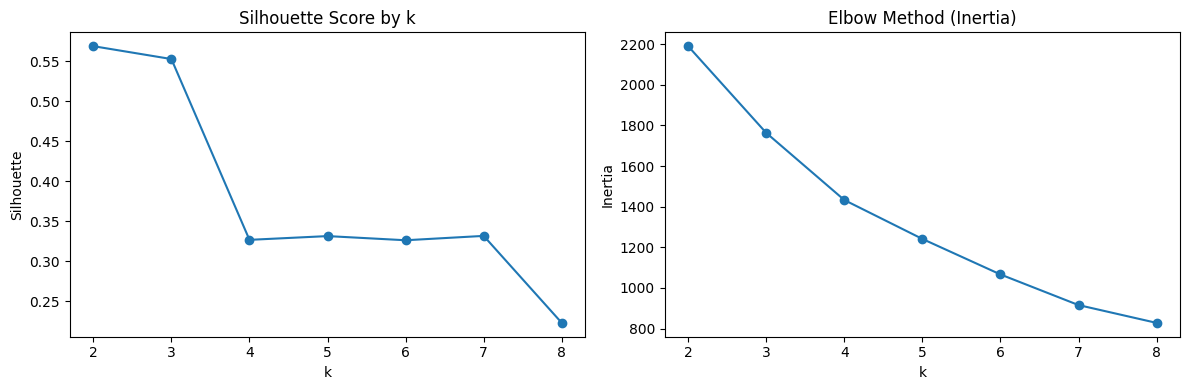

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_results['k'], k_results['silhouette'], marker='o')
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.subplot(1, 2, 2)
plt.plot(k_results['k'], k_results['inertia'], marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

## 14. Choose Best k

In [14]:
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print("Selected k:", best_k)

Selected k: 2


## 15. Fit Final Clustering on Train

In [15]:
model, scaler, train_labels, train_score, X_train_scaled = fit_kmeans(X_train, k=best_k)

train_clusters = pd.DataFrame({
    "Symbol": X_train.index,
    "Cluster_train": train_labels
})

print("Train silhouette:", round(train_score, 4))
train_clusters.head()

Train silhouette: 0.5692


,Symbol,Cluster_train
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,1
4,ABT,0


## 16. Evaluate Cluster Stability on Validation

In [16]:
X_val = aggregate_features(val, best_features)

common_train_val = X_train.index.intersection(X_val.index)
X_val = X_val.loc[common_train_val]

val_labels, val_score, X_val_scaled = apply_kmeans(X_val, model, scaler)

val_clusters = pd.DataFrame({
    "Symbol": X_val.index,
    "Cluster_val": val_labels
})

print("Validation silhouette:", round(val_score, 4))
val_clusters.head()

Validation silhouette: 0.5258


,Symbol,Cluster_val
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,0
4,ABT,0


## 17. Confirm Cluster Stability on Test

In [17]:
X_test = aggregate_features(test, best_features)

common_train_test = X_train.index.intersection(X_test.index)
X_test = X_test.loc[common_train_test]

test_labels, test_score, X_test_scaled = apply_kmeans(X_test, model, scaler)

test_clusters = pd.DataFrame({
    "Symbol": X_test.index,
    "Cluster_test": test_labels
})

print("Test silhouette:", round(test_score, 4))
test_clusters.head()

Test silhouette: 0.3748


,Symbol,Cluster_test
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,0
4,ABT,0


## 18. Stability Summary

In [18]:
stability_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "silhouette": [train_score, val_score, test_score]
})

stability_summary

,split,silhouette
0,train,0.569157
1,validation,0.525816
2,test,0.374775


## 19. Same-Stock Cluster Consistency

In [20]:
train_val_compare = train_clusters.merge(val_clusters, on="Symbol", how="inner")
train_test_compare = train_clusters.merge(test_clusters, on="Symbol", how="inner")

train_val_consistency = (train_val_compare["Cluster_train"] == train_val_compare["Cluster_val"]).mean()
train_test_consistency = (train_test_compare["Cluster_train"] == train_test_compare["Cluster_test"]).mean()

print("Train vs Validation consistency:", round(train_val_consistency, 4))
print("Train vs Test consistency:", round(train_test_consistency, 4))

Train vs Validation consistency: 0.8818
Train vs Test consistency: 0.8577


## 20. Cluster Profiles on Training Set

In [21]:
train_profile = X_train.copy()
train_profile["Cluster"] = train_labels

cluster_profile = train_profile.groupby("Cluster").mean()
cluster_profile

,logret_21,logvol_21,vol_chg_21,logret_21_std,logvol_21_std,vol_chg_21_std
Cluster,,,,,,
0,0.006950,0.01694,0.003339,0.077722,0.005479,0.530765
1,-0.001103,0.03186,0.006831,0.153690,0.012880,0.683821


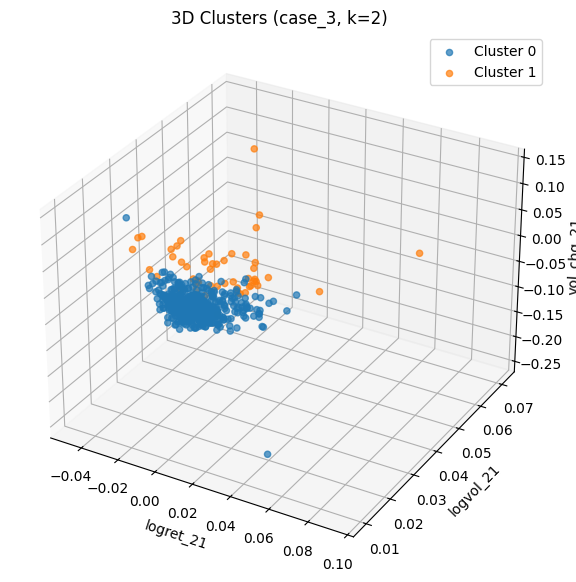

In [22]:
from mpl_toolkits.mplot3d import Axes3D

# get feature names for best case
feature_cols = FEATURE_CASES[best_case]

# use aggregated data (same used for clustering)
X_plot = X_train.copy()
X_plot['cluster'] = train_labels

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cluster in X_plot['cluster'].unique():
    subset = X_plot[X_plot['cluster'] == cluster]

    ax.scatter(
        subset[feature_cols[0]],
        subset[feature_cols[1]],
        subset[feature_cols[2]],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

ax.set_title(f"3D Clusters ({best_case}, k={best_k})")

ax.set_xlabel(feature_cols[0])
ax.set_ylabel(feature_cols[1])
ax.set_zlabel(feature_cols[2])

ax.legend()

plt.show()

## 21. PCA Visualization of Training Clusters

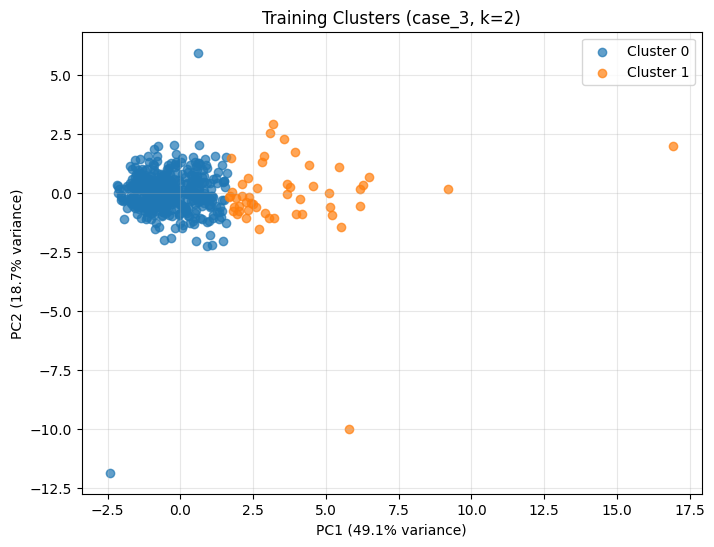

In [25]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Explained variance
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))

# Plot each cluster separately for proper labels
for cluster in np.unique(train_labels):
    mask = train_labels == cluster
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title(f"Training Clusters ({best_case}, k={best_k})")

# Better axis labels with variance explained
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
pd.Series(train_labels).value_counts()

0    448
1     51
Name: count, dtype: int64

## 22. Final Cluster Assignment Table

In [27]:
final_clusters = (
    train_clusters
    .merge(val_clusters, on="Symbol", how="left")
    .merge(test_clusters, on="Symbol", how="left")
)

final_clusters.head()

,Symbol,Cluster_train,Cluster_val,Cluster_test
0,A,0,0,0
1,AAPL,0,0,0
2,ABBV,0,0,0
3,ABNB,1,0,0
4,ABT,0,0,0


Sector counts by cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
cluster,,,,,,,,,,,
0,17,38,36,20,70,53,73,56,23,31,31
1,6,10,0,2,6,6,5,13,3,0,0


Sector percentages within each cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
cluster,,,,,,,,,,,
0,3.79,8.48,8.04,4.46,15.62,11.83,16.29,12.50,5.13,6.92,6.92
1,11.76,19.61,0.00,3.92,11.76,11.76,9.80,25.49,5.88,0.00,0.00


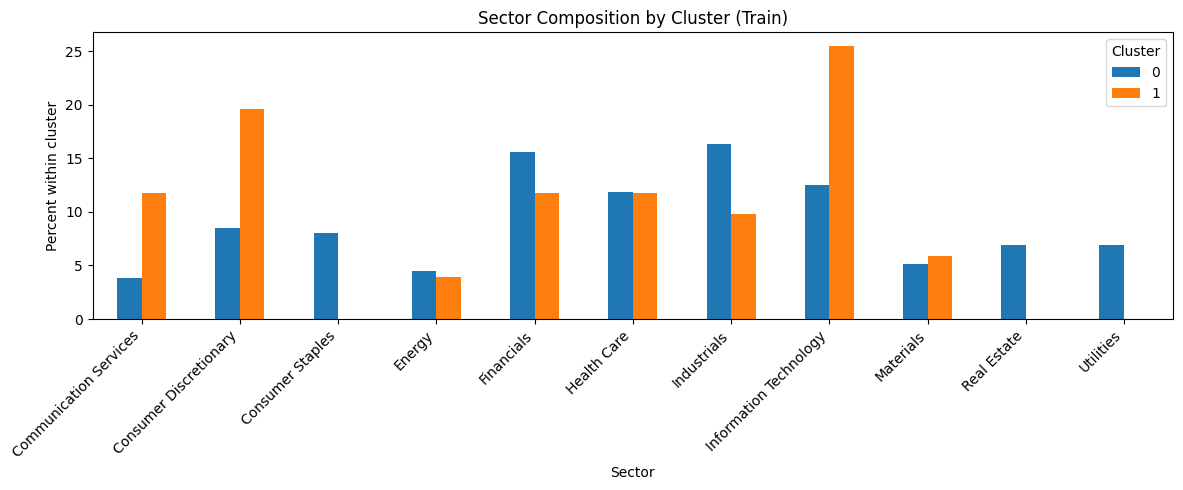

In [28]:
# Sector concentration test: are clusters economically interpretable?
if "Sector" in train.columns:
    sector_col = "Sector"
elif "GICS Sector" in train.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    symbol_sector = (
        train[["Symbol", sector_col]]
        .dropna()
        .drop_duplicates(subset=["Symbol"])
        .rename(columns={sector_col: "Sector"})
    )

    # stock-level cluster assignments
    train_clusters = X_train_with_labels[["cluster"]].reset_index()

    cluster_sector = (
        train_clusters
        .merge(symbol_sector, on="Symbol", how="left")
        .dropna(subset=["Sector"])
    )

    sector_counts = pd.crosstab(cluster_sector["cluster"], cluster_sector["Sector"])
    sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100

    print("Sector counts by cluster")
    display(sector_counts)

    print("Sector percentages within each cluster")
    display(sector_pct.round(2))

    ax = sector_pct.T.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Sector Composition by Cluster (Train)")
    ax.set_ylabel("Percent within cluster")
    ax.set_xlabel("Sector")
    ax.legend(title="Cluster")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Appendix

In [29]:
# Appendix experiment: single-horizon volume-change feature (vol_chg) for comparison

# Use same full feature table and split windows
train_app = full_feat[(full_feat['Date'] >= '2021-03-22') & (full_feat['Date'] <= '2024-03-21')].copy()
val_app   = full_feat[(full_feat['Date'] >= '2024-03-22') & (full_feat['Date'] <= '2025-03-21')].copy()
test_app  = full_feat[(full_feat['Date'] >= '2025-03-22') & (full_feat['Date'] <= '2026-03-21')].copy()

common_symbols_app = (
    set(train_app['Symbol'].unique())
    & set(val_app['Symbol'].unique())
    & set(test_app['Symbol'].unique())
)

train_app = train_app[train_app['Symbol'].isin(common_symbols_app)].copy()
val_app   = val_app[val_app['Symbol'].isin(common_symbols_app)].copy()
test_app  = test_app[test_app['Symbol'].isin(common_symbols_app)].copy()

FEATURE_CASES_APP = {
    "case_1_app": ['logret_1', 'logvol_1', 'vol_chg'],
    "case_2_app": ['logret_5', 'logvol_5', 'vol_chg'],
    "case_3_app": ['logret_21', 'logvol_21', 'vol_chg']
}

# 1) Compare feature cases on training
feature_case_results_app = []
for case_name_app, feature_cols_app in FEATURE_CASES_APP.items():
    X_train_case_app = aggregate_features(train_app, feature_cols_app)
    k_results_case_app, _ = evaluate_k_range(X_train_case_app, k_range=range(2, 9))

    best_idx_app = k_results_case_app['silhouette'].idxmax()
    best_k_case_app = int(k_results_case_app.loc[best_idx_app, 'k'])
    best_sil_case_app = float(k_results_case_app.loc[best_idx_app, 'silhouette'])

    feature_case_results_app.append({
        "case": case_name_app,
        "features": ", ".join(feature_cols_app),
        "n_stocks": len(X_train_case_app),
        "aggregated_feature_count": X_train_case_app.shape[1],
        "best_k": best_k_case_app,
        "best_train_silhouette": best_sil_case_app
    })

feature_case_results_app_df = (
    pd.DataFrame(feature_case_results_app)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

# 2) Select best case
best_case_app = feature_case_results_app_df.loc[0, 'case']
best_features_app = FEATURE_CASES_APP[best_case_app]

# 3) Build train matrix and choose k
X_train_app = aggregate_features(train_app, best_features_app)
k_results_app, _ = evaluate_k_range(X_train_app, k_range=range(2, 9))
best_k_app = int(k_results_app.loc[k_results_app['silhouette'].idxmax(), 'k'])

# 4) Fit final train clustering
model_app, scaler_app, train_labels_app, train_score_app, X_train_scaled_app = fit_kmeans(X_train_app, k=best_k_app)

train_clusters_app = pd.DataFrame({
    "Symbol": X_train_app.index,
    "Cluster_train_app": train_labels_app
})

# 5) Validation
X_val_app = aggregate_features(val_app, best_features_app)
common_train_val_app = X_train_app.index.intersection(X_val_app.index)
X_val_app = X_val_app.loc[common_train_val_app]

val_labels_app, val_score_app, X_val_scaled_app = apply_kmeans(X_val_app, model_app, scaler_app)
val_clusters_app = pd.DataFrame({
    "Symbol": X_val_app.index,
    "Cluster_val_app": val_labels_app
})

# 6) Test
X_test_app = aggregate_features(test_app, best_features_app)
common_train_test_app = X_train_app.index.intersection(X_test_app.index)
X_test_app = X_test_app.loc[common_train_test_app]

test_labels_app, test_score_app, X_test_scaled_app = apply_kmeans(X_test_app, model_app, scaler_app)
test_clusters_app = pd.DataFrame({
    "Symbol": X_test_app.index,
    "Cluster_test_app": test_labels_app
})

# 7) Stability summary
stability_summary_app = pd.DataFrame({
    "split": ["train_app", "validation_app", "test_app"],
    "silhouette": [train_score_app, val_score_app, test_score_app]
})

# 8) Same-stock consistency
train_val_compare_app = train_clusters_app.merge(val_clusters_app, on="Symbol", how="inner")
train_test_compare_app = train_clusters_app.merge(test_clusters_app, on="Symbol", how="inner")
train_val_consistency_app = (train_val_compare_app["Cluster_train_app"] == train_val_compare_app["Cluster_val_app"]).mean()
train_test_consistency_app = (train_test_compare_app["Cluster_train_app"] == train_test_compare_app["Cluster_test_app"]).mean()

# 9) Compare main pipeline vs appendix run
comparison_app = None
if all(v in globals() for v in ['best_case', 'best_k', 'train_score', 'val_score', 'test_score', 'train_val_consistency', 'train_test_consistency']):
    comparison_app = pd.DataFrame({
        "metric": [
            "best_case",
            "best_k",
            "train_silhouette",
            "validation_silhouette",
            "test_silhouette",
            "train_val_consistency",
            "train_test_consistency"
        ],
        "main_horizon_matched_volchg": [
            str(best_case),
            int(best_k),
            float(train_score),
            float(val_score),
            float(test_score),
            float(train_val_consistency),
            float(train_test_consistency)
        ],
        "appendix_single_volchg": [
            str(best_case_app),
            int(best_k_app),
            float(train_score_app),
            float(val_score_app),
            float(test_score_app),
            float(train_val_consistency_app),
            float(train_test_consistency_app)
        ]
    })

print('Appendix best case (single vol_chg):', best_case_app)
print('Appendix selected features:', best_features_app)
print('Appendix selected k:', best_k_app)
print('Appendix consistency (train-val, train-test):', round(train_val_consistency_app, 4), round(train_test_consistency_app, 4))

print()
print('Appendix feature case ranking:')
display(feature_case_results_app_df)

print()
print('Appendix stability summary:')
display(stability_summary_app)

if comparison_app is not None:
    print()
    print('Main (horizon-matched) vs Appendix (single vol_chg):')
    display(comparison_app)


Appendix best case (single vol_chg): case_2_app
Appendix selected features: ['logret_5', 'logvol_5', 'vol_chg']
Appendix selected k: 2
Appendix consistency (train-val, train-test): 0.8778 0.8236

Appendix feature case ranking:


,case,features,n_stocks,aggregated_feature_count,best_k,best_train_silhouette
0,case_2_app,"logret_5, logvol_5, vol_chg",499,6,2,0.548344
1,case_3_app,"logret_21, logvol_21, vol_chg",499,6,2,0.545155
2,case_1_app,"logret_1, logvol_1, vol_chg",499,6,2,0.527696



Appendix stability summary:


,split,silhouette
0,train_app,0.548344
1,validation_app,0.394848
2,test_app,0.281634



Main (horizon-matched) vs Appendix (single vol_chg):


,metric,main_horizon_matched_volchg,appendix_single_volchg
0,best_case,case_3,case_2_app
1,best_k,2,2
2,train_silhouette,0.569157,0.548344
3,validation_silhouette,0.54033,0.394848
4,test_silhouette,0.364405,0.281634
5,train_val_consistency,0.883768,0.877756
6,train_test_consistency,0.839679,0.823647


## 23. Cluster Profile Interpretation


In [30]:
# Compare cluster means in raw units and z-scores (train split)
train_profile_detail = X_train.copy()
train_profile_detail["Cluster"] = train_labels

cluster_profile_mean = train_profile_detail.groupby("Cluster")[best_features].mean()
overall_mean = X_train[best_features].mean()
overall_std = X_train[best_features].std(ddof=0).replace(0, np.nan)
cluster_profile_z = (cluster_profile_mean - overall_mean) / overall_std

print("Cluster profile: means")
display(cluster_profile_mean.round(4))

print("Cluster profile: z-score vs full train universe")
display(cluster_profile_z.round(3))

if cluster_profile_mean.shape[0] == 2:
    abs_diff = (cluster_profile_mean.iloc[1] - cluster_profile_mean.iloc[0]).abs().sort_values(ascending=False)
    print("Most separating features (absolute mean diff between Cluster 0 and 1)")
    display(abs_diff.to_frame("abs_diff").round(4))


Cluster profile: means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0069,0.0169,0.0033
1,-0.0011,0.0319,0.0068


Cluster profile: z-score vs full train universe


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.062,-0.242,-0.020
1,-0.548,2.128,0.172


Most separating features (absolute mean diff between Cluster 0 and 1)


,abs_diff
logvol_21,0.0149
logret_21,0.0081
vol_chg_21,0.0035


## 24. Sector Composition by Cluster (Train)


Sector counts by cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
Cluster_train,,,,,,,,,,,
0,17,38,36,20,70,53,73,56,23,31,31
1,6,10,0,2,6,6,5,13,3,0,0


Sector percentages within each cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
Cluster_train,,,,,,,,,,,
0,3.79,8.48,8.04,4.46,15.62,11.83,16.29,12.50,5.13,6.92,6.92
1,11.76,19.61,0.00,3.92,11.76,11.76,9.80,25.49,5.88,0.00,0.00


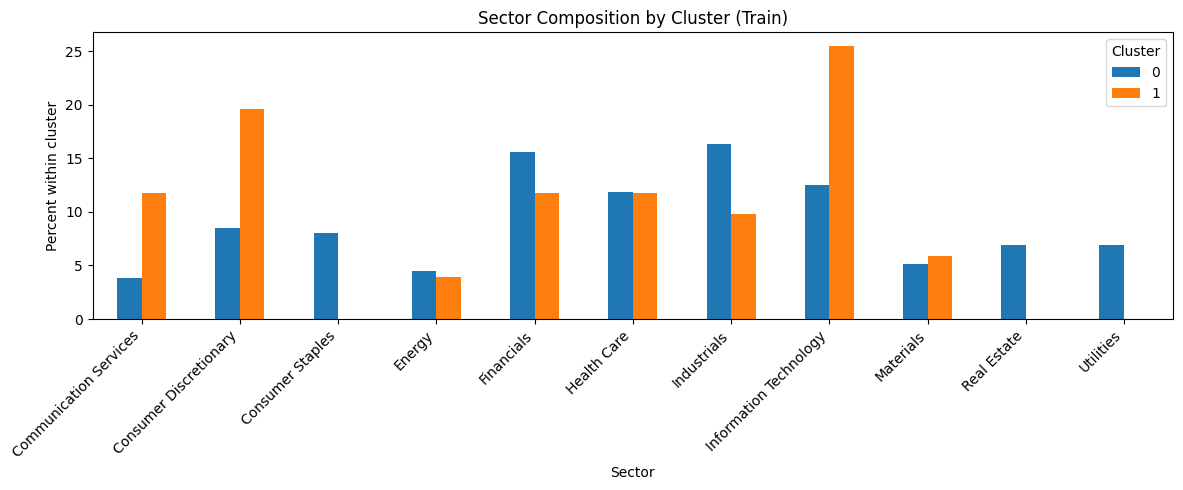

In [31]:
# Sector concentration test: are clusters economically interpretable?
if "Sector" in train.columns:
    sector_col = "Sector"
elif "GICS Sector" in train.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    symbol_sector = (
        train[["Symbol", sector_col]]
        .dropna()
        .drop_duplicates(subset=["Symbol"])
        .rename(columns={sector_col: "Sector"})
    )

    cluster_sector = train_clusters.merge(symbol_sector, on="Symbol", how="left").dropna(subset=["Sector"])

    sector_counts = pd.crosstab(cluster_sector["Cluster_train"], cluster_sector["Sector"])
    sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100

    print("Sector counts by cluster")
    display(sector_counts)

    print("Sector percentages within each cluster")
    display(sector_pct.round(2))

    ax = sector_pct.T.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Sector Composition by Cluster (Train)")
    ax.set_ylabel("Percent within cluster")
    ax.set_xlabel("Sector")
    ax.legend(title="Cluster")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 25. Out-of-Sample Stability Diagnostics


Cluster share by split (%)


,train,validation,test
0,89.78,89.38,80.56
1,10.22,10.62,19.44


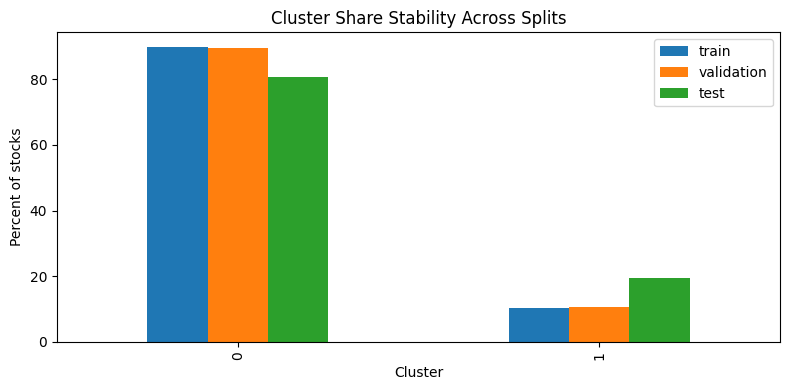

Train cluster feature means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0069,0.0169,0.0033
1,-0.0011,0.0319,0.0068


Validation cluster feature means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0076,0.0155,0.0187
1,-0.0019,0.0309,0.0486


Test cluster feature means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0104,0.0174,0.0006
1,0.0039,0.0304,0.0104


Validation minus train cluster means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0007,-0.0014,0.0153
1,-0.0008,-0.0010,0.0418


Test minus train cluster means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0034,0.0004,-0.0027
1,0.0051,-0.0015,0.0036


In [32]:
# Cluster size stability across train/validation/test
cluster_dist = pd.concat([
    train_clusters["Cluster_train"].value_counts(normalize=True).sort_index().rename("train"),
    val_clusters["Cluster_val"].value_counts(normalize=True).sort_index().rename("validation"),
    test_clusters["Cluster_test"].value_counts(normalize=True).sort_index().rename("test")
], axis=1).fillna(0)

print("Cluster share by split (%)")
display((cluster_dist * 100).round(2))

ax = (cluster_dist * 100).plot(kind="bar", figsize=(8, 4))
ax.set_title("Cluster Share Stability Across Splits")
ax.set_xlabel("Cluster")
ax.set_ylabel("Percent of stocks")
plt.tight_layout()
plt.show()

# Feature drift check: cluster means by split
train_means = X_train.assign(Cluster=train_labels).groupby("Cluster")[best_features].mean()
val_means = X_val.assign(Cluster=val_labels).groupby("Cluster")[best_features].mean()
test_means = X_test.assign(Cluster=test_labels).groupby("Cluster")[best_features].mean()

print("Train cluster feature means")
display(train_means.round(4))

print("Validation cluster feature means")
display(val_means.round(4))

print("Test cluster feature means")
display(test_means.round(4))

common_val = train_means.index.intersection(val_means.index)
common_test = train_means.index.intersection(test_means.index)

if len(common_val) > 0:
    print("Validation minus train cluster means")
    display((val_means.loc[common_val] - train_means.loc[common_val]).round(4))

if len(common_test) > 0:
    print("Test minus train cluster means")
    display((test_means.loc[common_test] - train_means.loc[common_test]).round(4))


## 26. Name the Clusters + Stock Examples


In [33]:
# Give human-readable names using volatility level
vol_cols = [c for c in best_features if c.startswith("logvol_")]
name_map = {}

if len(vol_cols) > 0 and cluster_profile_mean.shape[0] >= 2:
    vol_col = vol_cols[0]
    ordered = cluster_profile_mean[vol_col].sort_values()
    low_cluster = ordered.index[0]
    high_cluster = ordered.index[-1]

    name_map[low_cluster] = "Lower-vol / steadier"
    name_map[high_cluster] = "Higher-vol / more active"

for c in sorted(set(train_clusters["Cluster_train"])):
    name_map.setdefault(c, f"Cluster {c}")

train_clusters_named = train_clusters.copy()
train_clusters_named["Cluster_name"] = train_clusters_named["Cluster_train"].map(name_map)

print("Cluster naming map")
print(name_map)

cluster_sizes = train_clusters_named["Cluster_name"].value_counts().rename_axis("Cluster_name").reset_index(name="n_stocks")
print("Cluster sizes")
display(cluster_sizes)

stock_examples = (
    train_clusters_named.sort_values(["Cluster_name", "Symbol"])
    .groupby("Cluster_name")["Symbol"]
    .apply(lambda s: ", ".join(s.head(25)))
    .to_frame("example_symbols_first_25")
)

print("Stock examples by cluster")
display(stock_examples)


Cluster naming map
{np.int32(0): 'Lower-vol / steadier', np.int32(1): 'Higher-vol / more active'}
Cluster sizes


,Cluster_name,n_stocks
0,Lower-vol / steadier,448
1,Higher-vol / more active,51


Stock examples by cluster


,example_symbols_first_25
Cluster_name,
Higher-vol / more active,"ABNB, ALB, ALGN, AMD, APA, APP, AXON, BIIB, CC..."
Lower-vol / steadier,"A, AAPL, ABBV, ABT, ACGL, ACN, ADBE, ADI, ADM,..."
